# Browser Fingerprinting Layer Characterization

This notebook helps you to:

1. Load CSV with characterization of web agent across TLS, IP and Browser layers.
2. Display figures and precise number not included in the paper.
3. Reproduice table 11 of Appendix I.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./active_tests_browser_layers.csv")
agent_summary = df.groupby("tool").agg(
    num_fingerprints=("_id", "count"),
    jsFP_true=("jsFP", lambda x: (x == True).sum()),
    jsFP_false=("jsFP", lambda x: (x == False).sum()),
).reset_index()
# add percentage column
agent_summary["percent"] = (
    agent_summary["num_fingerprints"] / len(df) * 100
).round(2)
agent_summary

,tool,num_fingerprints,jsFP_true,jsFP_false,percent
0,Antropic Claude for Chrome,124,124,0,8.97
1,BrowserUse,378,378,0,27.33
2,ChatGPT Agent,65,65,0,4.70
3,Crawl4AI,150,150,0,10.85
4,Human,40,40,0,2.89
5,OpenClaw,111,108,3,8.03
6,Playwright,100,100,0,7.23
7,Puppeteer,99,99,0,7.16
8,Selenium,100,100,0,7.23
9,Skyvern,206,206,0,14.90


In [3]:
# Devide dataset into JS and no JS fingerprints
df = df.fillna("MISSING")
df_js = df[df["jsFP"] == True].copy()
df_nojs = df[df["jsFP"] == False].copy()
agent_summary = df_js.groupby("Agent").agg(
    num_fingerprints=("_id", "count"),
    jsFP_true=("jsFP", lambda x: (x == True).sum()),
    jsFP_false=("jsFP", lambda x: (x == False).sum()),
).reset_index()
# add percentage column
agent_summary["percent"] = (
    agent_summary["num_fingerprints"] / len(df_js) * 100
).round(2)
agent_summary

,Agent,num_fingerprints,jsFP_true,jsFP_false,percent
0,Antropic Claude for Chrome,124,124,0,9.05
1,BrowserUse_CLOUD,128,128,0,9.34
2,BrowserUse_LOCAL,130,130,0,9.49
3,BrowserUse_Stealth,120,120,0,8.76
4,ChatGPT Agent,65,65,0,4.74
5,Crawl4AI,50,50,0,3.65
6,Crawl4AI_Stealth,50,50,0,3.65
7,Crawl4AI_Undetected_Browser,50,50,0,3.65
8,Human,40,40,0,2.92
9,OpenClaw,108,108,0,7.88


## Intra-tool Value Probability ($Intra(A,v,t)$)

$Intra(A, v, t) = p(v \mid t) = \frac{\text{Count}(v, t)}{N_t}$

* This captures exactly how "typical" a value is for a specific tool. If a tool rotates 3 User-Agents equally, each will have an $Intra$ score of $0.33$

## Inter-tool Value Exclusivity ($Inter(A,v,t)$)

We define exclusivity based on how unlikely it is to encounter this specific value $v$ in any other tool ($¬t$).

$Excl(A, v, t) = 1 - p(v \mid \neg t) = 1 - \frac{\text{Count}(v, \neg t)}{N_{\neg t}}$

* This is a "Bayesian-style" likelihood check. It rewards values that are unique to the tool’s ecosystem, even if the tool doesn't use that value 100% of the time.

## Value Characterization Score ($V-Score$)

The quality of a specific value as a "fingerprint" for tool $t$ is the product of its typicality and its exclusivity:

$ V\text{-}Score(A, v, t) = p(v \mid t) \times (1 - p(v \mid \neg t)) ]$

## Attribute Characterization Score ($A-Score$)

To rank Attributes (to answer which attribute is most useful for identifying tool $t$), we aggregate the scores of all values that tool $t$ exhibits for that attribute:
$ A\text{-}Score(A, t) = \sum_{v \in Vals(A, t)} V\text{-}Score(A, v, t)$ 

In [4]:
def analyze_granular_signatures(df, target):
    exclude_cols = ["Web Agent", "tool", "Special prompt", "category", "_id", "timestamp", "siteKey", "jsFP", "cookieId", "Agent", "Agent LOCAL/CLOUD"]
    analysis_cols = [col for col in df.columns if col not in exclude_cols]
    df_clean = df.fillna('MISSING').astype(str)
    
    tools = df_clean[target].unique()
    value_results = []
    attribute_results = []

    for tool in tools:
        df_t = df_clean[df_clean[target] == tool]
        df_not_t = df_clean[df_clean[target] != tool]
        
        for col in analysis_cols:
            val_counts_t = df_t[col].value_counts(normalize=True)
            attr_total_score = 0
            
            for val, p_v_t in val_counts_t.items():
                # Inter-tool Exclusivity: 1 - p(v | not t)
                p_v_not_t = (df_not_t[col] == val).mean() if len(df_not_t) > 0 else 0
                exclusivity = 1 - p_v_not_t
                
                v_score = p_v_t * exclusivity
                attr_total_score += v_score
                
                value_results.append({
                    target: tool,
                    'attribute': col,
                    'value': val,
                    'intra_p': round(p_v_t, 4),
                    'excl_p': round(exclusivity, 4),
                    'v_score': round(v_score, 4)
                })
            
            attribute_results.append({
                target: tool,
                'attribute': col,
                'a_score': round(attr_total_score, 4)
            })

    df_values = pd.DataFrame(value_results)
    df_attrs = pd.DataFrame(attribute_results)

    # Output 1: Top Attributes per tool (aggregated)
    print("=== TOP 10 CHARACTERIZING ATTRIBUTES PER TOOL ===")
    for tool in tools:
        print(f"\nTool: {tool}")
        top_a = df_attrs[df_attrs[target] == tool].sort_values(by='a_score', ascending=False).head(10)
        print(top_a[['attribute', 'a_score']].to_string(index=False))

    # Output 2: Top Specific Values per tool (the "Smoking Guns")
    print("\n\n=== TOP 10 DISCRIMINATIVE VALUES (SIGNATURES) PER TOOL ===")
    for tool in tools:
        print(f"\nTool: {tool}")
        top_v = df_values[df_values[target] == tool].sort_values(by='v_score', ascending=False).head(10)
        print(top_v[['attribute', 'value','intra_p', 'excl_p' , 'v_score']].to_string(index=False))

    return df_values, df_attrs

In [5]:
df_js_copy = df_js.copy()
df_values_scores, df_attributes_scores = analyze_granular_signatures(df_js_copy, "Agent")
df_values_scores.to_csv("df_values_scores.csv", index=False)
df_attributes_scores.to_csv("df_attributes_scores.csv", index=False)

=== TOP 10 CHARACTERIZING ATTRIBUTES PER TOOL ===

Tool: Selenium
             attribute  a_score
   window_inner_height   1.0000
        content-length   0.9911
    window_outer_width   0.9594
   window_outer_height   0.9594
         client_height   0.9542
          client_width   0.9353
     resOverflow_depth   0.9237
connection-js_downlink   0.9057
                origin   0.9000
    window_inner_width   0.8945

Tool: Playwright
          attribute  a_score
window_outer_height   1.0000
      screen_height   1.0000
 screen_availHeight   1.0000
     content-length   0.9993
  resOverflow_depth   0.9850
       userAgent-js   0.9803
         user-agent   0.9803
 window_outer_width   0.9744
       languages-js   0.9512
       screen_width   0.9488

Tool: Puppeteer
             attribute  a_score
        content-length   0.9927
     resOverflow_depth   0.9718
            user-agent   0.9607
          userAgent-js   0.9607
   window_outer_height   0.9591
    window_outer_width   0.9591
    

In [6]:
def plot_score_heatmap(scores_df, pivot_col = "pivot",value_col="final_score", top_k_attributes=30, title=None):
    # keep globally most important attributes
    top_attrs = (
        scores_df.groupby("attribute")[value_col]
        .max()
        .sort_values(ascending=False)
        .head(top_k_attributes)
        .index
    )

    heatmap_df = scores_df[scores_df["attribute"].isin(top_attrs)].copy()

    pivot = heatmap_df.pivot(index=pivot_col, columns="attribute", values=value_col)
    pivot = pivot.loc[:, pivot.max().sort_values(ascending=False).index]

    plt.figure(figsize=(max(12, len(pivot.columns) * 0.5), max(4, len(pivot.index) * 0.6)))
    plt.imshow(pivot.fillna(0).values, aspect="auto")
    plt.colorbar(label=value_col)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title(title if title else f"Heatmap of {value_col}")
    plt.tight_layout()
    plt.show()

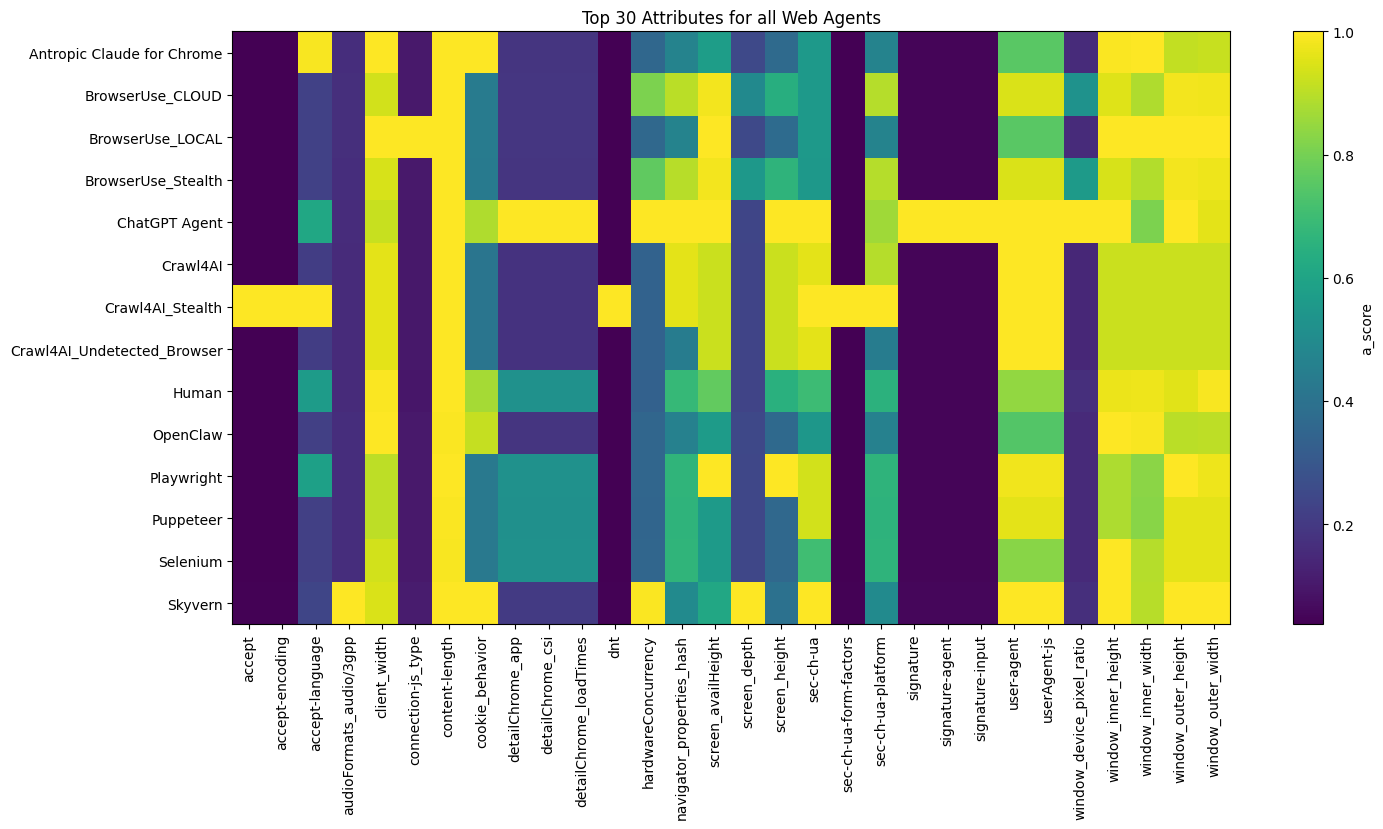

In [7]:
plot_score_heatmap(df_attributes_scores,"Agent", "a_score", 30, "Top 30 Attributes for all Web Agents")

/tmp/ipykernel_37393/3193824218.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


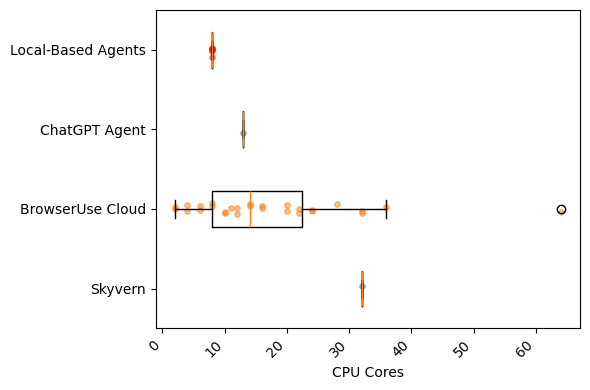

In [8]:
# Boxplot for hardwareConcurrency
categories = { 
    "Antropic Claude for Chrome": "Local-Based Agents",
    "BrowserUse_LOCAL" : "Local-Based Agents",
    "BrowserUse_Stealth": "BrowserUse Cloud",
    "BrowserUse_CLOUD": "BrowserUse Cloud",
    "ChatGPT Agent": "ChatGPT Agent",
    "Crawl4AI": "Local-Based Agents",
    "Crawl4AI_Stealth": "Local-Based Agents",
    "Crawl4AI_Undetected_Browser": "Local-Based Agents",
    "OpenClaw": "Local-Based Agents",
    "Skyvern": "Skyvern"
}

# Filter attribute
df_hw = df_values_scores[
    df_values_scores["attribute"] == "hardwareConcurrency"
].copy()

# Convert to numeric
df_hw["value"] = pd.to_numeric(df_hw["value"], errors="coerce")
df_hw = df_hw.dropna(subset=["value"])

# Aggregate agents
df_hw["AgentGroup"] = df_hw["Agent"].map(categories)
df_hw = df_hw.dropna(subset=["AgentGroup"])

# Desired ordering
cloud_agents = [
    "Skyvern",
    "BrowserUse Cloud",
    "ChatGPT Agent"
]

local_agents = [
    "Local-Based Agents"
]

agents = (
    cloud_agents +
    local_agents
)

# Prepare boxplot data
data = []

for agent in agents:
    if agent == "":
        data.append([np.nan])  # separator
    else:
        values = df_hw[
            df_hw["AgentGroup"] == agent
        ]["value"].values
        data.append(values)

# Plot
plt.figure(figsize=(6, 4))

plt.boxplot(
    data,
    labels=agents,
    vert=False   # horizontal boxplot
)

# Add points
for i, agent in enumerate(agents, start=1):

    x = df_hw[df_hw["AgentGroup"] == agent]["value"].values
    y = np.random.normal(i, 0.04, size=len(x))

    plt.scatter(x, y, alpha=0.5, s=15)


plt.xticks(rotation=45, ha="right")

plt.xlabel("CPU Cores")

plt.tight_layout()
plt.savefig("hardware_concurrency_boxplot.svg", format="svg", bbox_inches="tight")
plt.show()

=== TOP 10 CHARACTERIZING ATTRIBUTES PER TOOL ===

Tool: Browser Automation
         attribute  a_score
        User Agent   0.9402
 Permissions State   0.8964
 Screen Resolution   0.5594
Cookies Management   0.5070
         CPU Cores   0.4192
   signature-agent   0.0607
           Referer   0.0467

Tool: Crawl4AI
         attribute  a_score
        User Agent   1.0000
 Permissions State   0.9621
 Screen Resolution   0.9242
Cookies Management   0.4114
         CPU Cores   0.3402
   signature-agent   0.0492
           Referer   0.0379

Tool: Crawl4AI-Stealth
         attribute  a_score
        User Agent   1.0000
           Referer   1.0000
 Permissions State   0.9621
 Screen Resolution   0.9242
Cookies Management   0.4114
         CPU Cores   0.3402
   signature-agent   0.0492

Tool: Crawl4AI-Undetected-Browser
         attribute  a_score
        User Agent   1.0000
 Screen Resolution   0.9242
 Permissions State   0.7333
Cookies Management   0.4114
         CPU Cores   0.3402
   signat

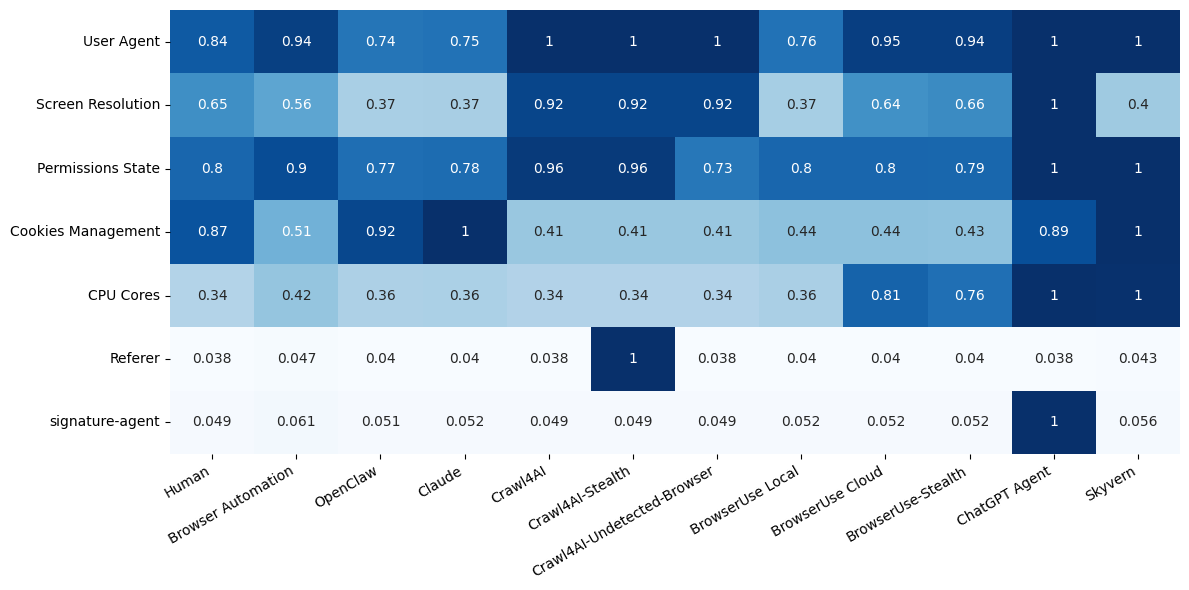

In [9]:
import seaborn as sns

attribute_categories = {
    "User Agent": [
        "userAgent-js"
    ],
    
    "Screen Resolution": [
        "screen_width",
        "screen_height",
    ],

    "Permissions State": [
        "permissions_microphone",
        "permissions_background-sync",
        "permissions_payment-handler",
        "permissions_persistent-storage",
        "permissions_geolocation",
        "permissions_accelerometer",
        "permissions_magnetometer",
        "permissions_camera",
        "permissions_push",
        "permissions_clipboard-read",
        "permissions_clipboard-write",
        "permissions_midi",
        "permissions_notifications",
    ],

    "Cookies Management": [
        "cookie_behavior",
    ],

    "CPU Cores": [
        "hardwareConcurrency",
    ],

    "Referer": ["referer"],
    
    "signature-agent": ["signature-agent"],
}

# Desired display order on X axis
target_order = [
    "Human",
    "Browser Automation",
    "OpenClaw",
    "Claude",
    "Crawl4AI",
    "Crawl4AI-Stealth",
    "Crawl4AI-Undetected-Browser",
    "BrowserUse Local",
    "BrowserUse Cloud",
    "BrowserUse-Stealth",
    "ChatGPT Agent",
    "Skyvern",
]

agent_groups = {
    "Playwright": "Browser Automation",
    "Puppeteer": "Browser Automation",
    "Selenium": "Browser Automation",

    "BrowserUse_CLOUD": "BrowserUse Cloud",
    "BrowserUse_Stealth": "BrowserUse-Stealth",
    "BrowserUse_LOCAL": "BrowserUse Local",

    "Crawl4AI": "Crawl4AI",
    "Crawl4AI_Stealth": "Crawl4AI-Stealth",
    "Crawl4AI_Undetected_Browser": "Crawl4AI-Undetected-Browser",

    "ChatGPT Agent": "ChatGPT Agent",
    "Skyvern": "Skyvern",
    "OpenClaw": "OpenClaw",
    "Antropic Claude for Chrome": "Claude",
    "Human": "Human",
}

def build_category_level_df(df, target, attribute_categories):
    rows = []

    for _, row in df.iterrows():
        new_row = {target: agent_groups.get(row[target], row[target])}

        for category, attrs in attribute_categories.items():
            existing_attrs = [a for a in attrs if a in df.columns]

            new_row[category] = " | ".join(
                str(row[attr])
                for attr in existing_attrs
                if pd.notna(row[attr])
            )

        rows.append(new_row)

    return pd.DataFrame(rows)


df_js_cat = build_category_level_df(
    df_js.copy(),
    target="Agent",
    attribute_categories=attribute_categories
)

df_values_cat_scores, df_attributes_cat_scores = analyze_granular_signatures(
    df_js_cat,
    "Agent"
)

df_top_vscores = (
    df_values_cat_scores
    .sort_values("v_score", ascending=False)
    .drop_duplicates(subset=["attribute", "Agent"])
)


# Pivot with attributes in Y axis and targets in X axis
heatmap_data = df_attributes_cat_scores.pivot(
    index="attribute",
    columns="Agent",
    values="a_score"
).fillna(0)
attribute_order = [
    "User Agent",
    "Screen Resolution",
    "Permissions State",
    "Cookies Management",
    "CPU Cores",
    "Referer",
    "signature-agent",
]
# Apply desired target order
heatmap_data = heatmap_data.reindex(index=attribute_order, columns=target_order)

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    cmap="Blues",
    cbar=False, 
    annot=True
)

plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("category_heatmap.svg", format="svg", bbox_inches="tight")
plt.show()